# Lab 3: Classification and Modern AI in R

In this lab, we study **classification**, where the goal is to predict a category.

We will use the Titanic dataset to answer the question:

> Can we predict whether a passenger survived?

The lab has two parts:

- **Part I: Classification** using decision trees and random forests
- **Part II: Modern AI** using large language models from R


### <div class="alert alert-block alert-success"> Section 1: Business Understanding and Data Exploration </div>

In classification problems, the outcome is categorical.

Examples:

- Spam or not spam
- Disease or no disease
- Fraud or not fraud
- Survived or did not survive

In this case study, we use passenger information from the Titanic to predict survival.


#### <div class="alert alert-block alert-success"> 1.1 Loading Packages </div>

We will use several R packages:

- `data.table` for fast data manipulation
- `tidyverse` for data visualization and data wrangling
- `rpart` and `rpart.plot` for decision trees
- `randomForest` for random forest classification


In [ ]:
install.packages("randomForest")

In [ ]:
install.packages("rpart.plot")

In [ ]:
# Install packages if needed
# install.packages(c("data.table", "tidyverse", "rpart", "rpart.plot", "randomForest", "caret"))

library(data.table)
library(tidyverse)
library(rpart)
library(rpart.plot)
library(randomForest)
library(caret)

#### <div class="alert alert-block alert-success"> 1.2 Downloading and Saving the Titanic Dataset </div>

The Titanic dataset can be downloaded from a public GitHub source.

We will also save a copy into the `data/` folder so that future notebooks can use the local file.


In [ ]:
# Create data folder if it does not exist
if (!dir.exists("data")) {
  dir.create("data")
}

url <- "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

titanic <- fread(url)

fwrite(titanic, "data/titanic.csv")

head(titanic)

In [62]:
titanic <- fread("data/titanic.csv")

In [65]:
titanic[100]

PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
<int>,<int>,<int>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>
100,0,2,"Kantor, Mr. Sinai",male,34,1,0,244367,26,,S


[Titanic Data Dictionary](https://choens.github.io/titanic/workshops/regression/data-dictionary/)

#### <div class="alert alert-block alert-success"> 1.3 First Look at the Dataset </div>

Before modeling, always inspect the dataset.

Important questions:

- How many passengers are included?
- What variables are available?
- Which variable should be predicted?
- Are there missing values?


In [63]:
dim(titanic)
names(titanic)
str(titanic)
summary(titanic)

[1] 891  12

[1] "PassengerId" "Survived"    "Pclass"      "Name"        "Sex"        
 [6] "Age"         "SibSp"       "Parch"       "Ticket"      "Fare"       
[11] "Cabin"       "Embarked"

Classes ‘data.table’ and 'data.frame':	891 obs. of  12 variables:
 $ PassengerId: int  1 2 3 4 5 6 7 8 9 10 ...
 $ Survived   : int  0 1 1 1 0 0 0 0 1 1 ...
 $ Pclass     : int  3 1 3 1 3 3 1 3 3 2 ...
 $ Name       : chr  "Braund, Mr. Owen Harris" "Cumings, Mrs. John Bradley (Florence Briggs Thayer)" "Heikkinen, Miss. Laina" "Futrelle, Mrs. Jacques Heath (Lily May Peel)" ...
 $ Sex        : chr  "male" "female" "female" "female" ...
 $ Age        : num  22 38 26 35 35 NA 54 2 27 14 ...
 $ SibSp      : int  1 1 0 1 0 0 0 3 0 1 ...
 $ Parch      : int  0 0 0 0 0 0 0 1 2 0 ...
 $ Ticket     : chr  "A/5 21171" "PC 17599" "STON/O2. 3101282" "113803" ...
 $ Fare       : num  7.25 71.28 7.92 53.1 8.05 ...
 $ Cabin      : chr  "" "C85" "" "C123" ...
 $ Embarked   : chr  "S" "C" "S" "S" ...
 - attr(*, ".internal.selfref")=<externalptr> 


  PassengerId       Survived          Pclass          Name          
 Min.   :  1.0   Min.   :0.0000   Min.   :1.000   Length:891        
 1st Qu.:223.5   1st Qu.:0.0000   1st Qu.:2.000   Class :character  
 Median :446.0   Median :0.0000   Median :3.000   Mode  :character  
 Mean   :446.0   Mean   :0.3838   Mean   :2.309                     
 3rd Qu.:668.5   3rd Qu.:1.0000   3rd Qu.:3.000                     
 Max.   :891.0   Max.   :1.0000   Max.   :3.000                     
                                                                    
     Sex                 Age            SibSp           Parch       
 Length:891         Min.   : 0.42   Min.   :0.000   Min.   :0.0000  
 Class :character   1st Qu.:20.12   1st Qu.:0.000   1st Qu.:0.0000  
 Mode  :character   Median :28.00   Median :0.000   Median :0.0000  
                    Mean   :29.70   Mean   :0.523   Mean   :0.3816  
                    3rd Qu.:38.00   3rd Qu.:1.000   3rd Qu.:0.0000  
                    Max.   :80.00 

#### <div class="alert alert-block alert-success"> 1.4 Understanding the Response Variable </div>

The response variable is `Survived`.

- `0` means the passenger did not survive.
- `1` means the passenger survived.

For classification, we convert this variable into a factor.


In [ ]:
titanic[, Survived := factor(
  Survived,
  levels = c(0, 1),
  labels = c("No", "Yes")
)]

table(titanic$Survived)

#### <div class="alert alert-block alert-success"> 1.5 Missing Values </div>

Real datasets often contain missing values.

Let us check how many missing values appear in each variable.


In [ ]:
missing_summary <- data.table(
  variable = names(titanic),
  missing_count = colSums(is.na(titanic))
)

missing_summary[, missing_percent := round(100 * missing_count / nrow(titanic), 2)]

missing_summary[order(-missing_count)]

#### <div class="alert alert-block alert-success"> 1.6 Basic Survival Rate </div>

A simple first question:

> What percentage of passengers survived?


In [ ]:
survival_rate <- titanic[ , .N, by = Survived]

survival_rate[, percent := round(100 * N / sum(N), 1)]

survival_rate

### <div class="alert alert-block alert-success"> Section 2: Exploratory Data Analysis </div>

Before building models, we should explore the data visually.

We will examine survival patterns by:

- Sex
- Passenger class
- Age
- Fare


#### <div class="alert alert-block alert-success"> 2.1 Survival by Sex </div>

Question:

> Did survival rates differ by sex?


In [ ]:
ggplot(titanic, aes(x = Sex, fill = Survived)) +
  geom_bar(position = "fill") +
  labs(
    title = "Survival Rate by Sex",
    x = "Sex",
    y = "Proportion",
    fill = "Survived"
  ) +
  theme_minimal(base_size = 14)

#### <div class="alert alert-block alert-success"> 2.2 Survival by Passenger Class </div>

Question:

> Did passenger class relate to survival?


In [ ]:
ggplot(titanic, aes(x = factor(Pclass), fill = Survived)) +
  geom_bar(position = "fill") +
  labs(
    title = "Survival Rate by Passenger Class",
    x = "Passenger Class",
    y = "Proportion",
    fill = "Survived"
  ) +
  theme_minimal(base_size = 14)

#### <div class="alert alert-block alert-success"> 2.3 Age Distribution by Survival Status </div>

Question:

> Were survivors generally younger or older than non-survivors?


In [ ]:
ggplot(titanic, aes(x = Survived, y = Age)) +
  geom_boxplot() +
  labs(
    title = "Age Distribution by Survival Status",
    x = "Survived",
    y = "Age"
  ) +
  theme_minimal(base_size = 14)

#### <div class="alert alert-block alert-success"> 2.4 Fare Distribution by Survival Status </div>

Question:

> Did passengers who paid higher fares have different survival patterns?


In [ ]:
ggplot(titanic, aes(x = Survived, y = Fare)) +
  geom_boxplot() +
  labs(
    title = "Fare Distribution by Survival Status",
    x = "Survived",
    y = "Fare"
  ) +
  theme_minimal(base_size = 14)

In [ ]:
ggplot(titanic, aes(x = Survived, y = Fare)) +
  geom_boxplot() +
  labs(
    title = "Fare Distribution by Survival Status",
    x = "Survived",
    y = "Fare"
  ) +
  theme_minimal(base_size = 14) +
  ylim(c(0,100))

#### <div class="alert alert-block alert-success"> 2.5 Discussion </div>

Based on the plots:

1. Which variables seem related to survival?
2. Which variable appears most important?
3. Are there any variables that may need preprocessing before modeling?


### <div class="alert alert-block alert-success"> Section 3: Data Preprocessing for Classification </div>

Machine learning models require clean and organized data.

For this lab, we will create a simplified analysis dataset using:

- `Survived`
- `Pclass`
- `Sex`
- `Age`
- `SibSp`
- `Parch`
- `Fare`
- `Embarked`

We will also create a new variable called `FamilySize`.


#### <div class="alert alert-block alert-success"> 3.1 Selecting Variables </div>

In [ ]:
titanic_model <- titanic[, .(
    Survived,
    Pclass,
    Sex,
    Age,
    SibSp,
    Parch,
    Fare,
    Embarked
  )
]

head(titanic_model)

#### <div class="alert alert-block alert-success"> 3.2 Creating Family Size </div>

A passenger's family size may affect survival.

We define:

```text
FamilySize = SibSp + Parch + 1
```

The `+1` includes the passenger.


In [ ]:
titanic_model[, FamilySize := SibSp + Parch + 1]

head(titanic_model)

#### <div class="alert alert-block alert-success"> 3.3 Handling Missing Age Values </div>

The `Age` variable has missing values.

A simple strategy is to replace missing ages with the median age.

In [ ]:
median_age <- median(titanic_model$Age, na.rm = TRUE)

titanic_model[is.na(Age), Age := median_age]

sum(is.na(titanic_model$Age))

#### <div class="alert alert-block alert-success"> 3.4 Handling Missing Embarked Values </div>

The `Embarked` variable indicates where the passenger boarded.

If missing, we replace it with the most common value.


In [ ]:
table(titanic_model$Embarked, useNA = "ifany")

In [ ]:
most_common_embarked <- names(sort(table(titanic_model$Embarked), decreasing = TRUE))[1]

titanic_model[is.na(Embarked) | Embarked == "", Embarked := most_common_embarked]

table(titanic_model$Embarked, useNA = "ifany")

#### <div class="alert alert-block alert-success"> 3.5 Converting Variables to Factors </div>

Categorical variables should be treated as factors.


In [ ]:
titanic_model[, Pclass := factor(Pclass)]
titanic_model[, Sex := factor(Sex)]
titanic_model[, Embarked := factor(Embarked)]

str(titanic_model)

#### <div class="alert alert-block alert-success"> 3.6 Final Check </div>

In [ ]:
colSums(is.na(titanic_model))
summary(titanic_model)

### <div class="alert alert-block alert-success"> Section 4: Training and Testing </div>

A model should work well on new data, not just data it has already seen.

We split the dataset into:

- **Training data**: used to build the model
- **Testing data**: used to evaluate the model


#### <div class="alert alert-block alert-success"> 4.1 Train-Test Split </div>

In [ ]:
set.seed(123)

train_index <- sample(1:nrow(titanic_model), size = round(0.8 * nrow(titanic_model)))

train <- titanic_model[train_index]
test  <- titanic_model[-train_index]

dim(train)
dim(test)

#### <div class="alert alert-block alert-success"> 4.2 Baseline Model </div>

Before fitting machine learning models, we should create a simple baseline.

A baseline prediction could be:

> Always predict the most common class.

This gives us something to compare against.


In [ ]:
table(train$Survived)

baseline_class <- names(which.max(table(train$Survived)))

baseline_pred <- factor(
  rep(baseline_class, nrow(test)),
  levels = levels(test$Survived)
)

mean(baseline_pred == test$Survived)

### <div class="alert alert-block alert-success"> Section 5: Decision Tree Classification </div>

A decision tree uses a sequence of simple rules.

For example:

```text
If passenger is female:
    predict survived
else:
    check passenger class
```

Decision trees are easy to visualize and interpret.


#### <div class="alert alert-block alert-success"> 5.1 Fitting a Decision Tree </div>

In [ ]:
tree_model <- rpart(
  Survived ~ Pclass + Sex + Age + FamilySize + Fare + Embarked,
  data = train,
  method = "class"
)

tree_model

#### <div class="alert alert-block alert-success"> 5.2 Plotting the Decision Tree </div>

In [68]:
pdf(
  "pics/titanic_tree.pdf",
  width = 8,
  height = 6
)

rpart.plot(
  tree_model,
  type = 2,
  extra = 104,
  fallen.leaves = TRUE,
  main = "Decision Tree for Titanic Survival"
)

dev.off()

pdf 
  2

#### <div class="alert alert-block alert-success"> 5.3 Making Predictions </div>

In [ ]:
tree_pred <- predict(
  tree_model,
  newdata = test,
  type = "class"
)

head(tree_pred)

#### <div class="alert alert-block alert-success"> 5.4 Confusion Matrix and Accuracy </div>

A confusion matrix compares predicted classes with actual classes.


In [ ]:
confusionMatrix(
  tree_pred,
  test$Survived,
  positive = "Yes"
)

In [ ]:
tree_accuracy <- mean(tree_pred == test$Survived)

tree_accuracy

#### <div class="alert alert-block alert-success"> 5.5 Discussion </div>

Questions:

1. What is the first split in the tree?
2. Which variables are used by the tree?
3. Does the decision tree perform better than the baseline?
4. Is the decision tree easy to explain?


### <div class="alert alert-block alert-success"> Section 6: Random Forest Classification </div>

A random forest combines many decision trees.

Idea:

> One tree may make mistakes, but many trees can vote together.

Random forests are often more accurate than a single decision tree.


#### <div class="alert alert-block alert-success"> 6.1 Fitting a Random Forest </div>

In [ ]:
set.seed(123)

rf_model <- randomForest(
  Survived ~ Pclass + Sex + Age + FamilySize + Fare + Embarked,
  data = train,
  ntree = 300,
  importance = TRUE
)

rf_model

#### <div class="alert alert-block alert-success"> 6.2 Making Predictions </div>

In [ ]:
rf_pred <- predict(
  rf_model,
  newdata = test
)

head(rf_pred)

#### <div class="alert alert-block alert-success"> 6.3 Random Forest Accuracy </div>

In [ ]:
confusionMatrix(
  rf_pred,
  test$Survived,
  positive = "Yes"
)

In [ ]:
rf_accuracy <- mean(rf_pred == test$Survived)

rf_accuracy

#### <div class="alert alert-block alert-success"> 6.4 Comparing Models </div>

In [ ]:
model_comparison <- data.table(
  Model = c(
    "Baseline",
    "Decision Tree",
    "Random Forest"
  ),
  Accuracy = c(
    mean(baseline_pred == test$Survived),
    tree_accuracy,
    rf_accuracy
  )
)

model_comparison

In [ ]:
ggplot(
  model_comparison,
  aes(x = Model, y = Accuracy)
) +
  geom_col() +
  ylim(0, 1) +
  labs(
    title = "Model Accuracy Comparison",
    x = "Model",
    y = "Testing Accuracy"
  ) +
  theme_minimal(base_size = 14)

#### <div class="alert alert-block alert-success"> 6.5 Feature Importance </div>

Random forests can help us identify which variables are most useful for prediction.


In [ ]:
importance(rf_model)

In [ ]:
varImpPlot(
  rf_model,
  main = "Variable Importance in Random Forest"
)

#### <div class="alert alert-block alert-success"> 6.6 Discussion </div>

Questions:

1. Which model has the highest testing accuracy?
2. Which variables appear most important?
3. Is a random forest easier or harder to interpret than a single tree?
4. Why might many trees perform better than one tree?


### <div class="alert alert-block alert-success"> Section 7: Mini Classification Challenge </div>

Work with a partner.

Your goal is to build and evaluate a classification model.

Choose at least two models:

- Baseline
- Decision tree
- Random forest

Then compare their testing accuracy.


#### <div class="alert alert-block alert-success"> 7.1 Build Your Own Decision Tree </div>

Try changing the predictors in the model.


In [ ]:
# Example: edit the predictors below
my_tree <- rpart(
  Survived ~ Sex + Pclass + Age,
  data = train,
  method = "class"
)

my_tree_pred <- predict(
  my_tree,
  newdata = test,
  type = "class"
)

mean(my_tree_pred == test$Survived)

#### <div class="alert alert-block alert-success"> 7.2 Build Your Own Random Forest </div>

In [ ]:
# Example: edit the predictors below
set.seed(123)

my_rf <- randomForest(
  Survived ~ Sex + Pclass + Age + Fare,
  data = train,
  ntree = 300
)

my_rf_pred <- predict(
  my_rf,
  newdata = test
)

mean(my_rf_pred == test$Survived)

#### <div class="alert alert-block alert-success"> 7.3 Report Your Result </div>

Fill in:

```text
My best model was:

Testing accuracy:

The most important predictors were:

One thing I learned from this dataset:
```


### <div class="alert alert-block alert-success"> Section 8: Modern AI and Large Language Models </div>

So far, we have used traditional machine learning models:

- Decision tree
- Random forest

Modern AI also includes large language models, or LLMs.

Examples include:

- ChatGPT
- Claude
- Gemini
- Copilot

Large language models are trained on large collections of text and can generate responses, explanations, summaries, and code.


#### <div class="alert alert-block alert-success"> 8.1 What Can an LLM Do for Data Science? </div>

An LLM can help with:

- Explaining code
- Suggesting visualizations
- Summarizing results
- Generating hypotheses
- Drafting reports

But we should not blindly trust an LLM.

A data scientist must still check results carefully.


#### <div class="alert alert-block alert-success"> 8.2 Optional: Using ellmer in R </div>

The `ellmer` package allows R users to interact with large language models.

This section is optional because it may require an API key or institutional setup.


In [ ]:
install.packages("ellmer")

In [ ]:
# Optional only
# install.packages("ellmer")
# library(ellmer)

# Example structure:
# chat <- chat_openai()
#
# chat$chat(
#   "Explain what a decision tree is to a high school student."
# )

#### <div class="alert alert-block alert-success"> 8.3 LLM Prompting Activity </div>

If an LLM is available, try asking:

```text
We analyzed the Titanic dataset using a decision tree and random forest.
Survival was predicted using passenger class, sex, age, fare, family size, and embarkation port.
Please summarize what variables might be important and explain why.
```

Then compare the LLM response with your actual model results.

Questions:

1. Does the LLM agree with the model?
2. Did it make any unsupported claims?
3. What information should we verify using data?


#### <div class="alert alert-block alert-success"> 8.4 Responsible AI Discussion </div>

Large language models are powerful, but they can make mistakes.

Important reminders:

- Always verify important claims.
- Do not upload private or sensitive data.
- Use AI as an assistant, not as a replacement for your own thinking.
- Ask: "What evidence supports this answer?"


### <div class="alert alert-block alert-success"> Section 9: Lab Summary </div>

Today we learned how to:

- Define a classification problem
- Explore a real dataset
- Prepare data for modeling
- Split data into training and testing sets
- Fit a decision tree
- Fit a random forest
- Evaluate accuracy using a confusion matrix
- Compare models
- Interpret feature importance
- Discuss how modern AI can support data science

Key takeaway:

> Classification predicts categories, and model performance should be evaluated on new data.

In the next stage of the camp, you will use these ideas to develop your team project.


SVN

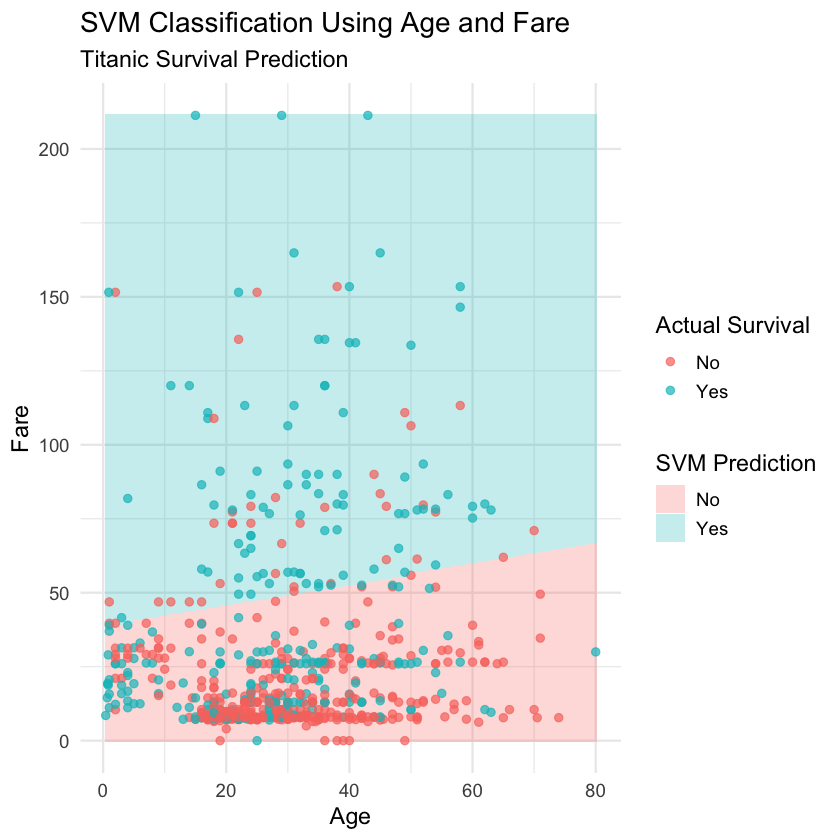

In [72]:
library(data.table)
library(ggplot2)
library(e1071)

# Load Titanic data
titanic <- fread("data/titanic.csv")

# Keep complete cases
svm_data <- titanic[
  !is.na(Age) &
  !is.na(Fare) &
  !is.na(Survived),
  .(
    Age,
    Fare,
    Survived = factor(
      Survived,
      levels = c(0, 1),
      labels = c("No", "Yes")
    )
  )
]

# Optional: trim extreme fares for nicer visualization
fare_cut <- quantile(
  svm_data$Fare,
  0.98
)

svm_data <- svm_data[
  Fare <= fare_cut
]

# Fit linear SVM
svm_fit <- svm(
  Survived ~ Age + Fare,
  data = svm_data,
  kernel = "linear",
  cost = 1,
  scale = TRUE
)

# Create prediction grid
grid <- expand.grid(
  Age = seq(
    min(svm_data$Age),
    max(svm_data$Age),
    length.out = 300
  ),
  Fare = seq(
    min(svm_data$Fare),
    max(svm_data$Fare),
    length.out = 300
  )
)

grid <- as.data.table(grid)

grid[
  ,
  pred := predict(
    svm_fit,
    newdata = grid
  )
]

# Plot decision regions
p_svm <- ggplot() +
  geom_tile(
    data = grid,
    aes(
      Age,
      Fare,
      fill = pred
    ),
    alpha = 0.25
  ) +
  geom_point(
    data = svm_data,
    aes(
      Age,
      Fare,
      color = Survived
    ),
    alpha = 0.7,
    size = 2
  ) +
  labs(
    title = "SVM Classification Using Age and Fare",
    subtitle = "Titanic Survival Prediction",
    x = "Age",
    y = "Fare",
    color = "Actual Survival",
    fill = "SVM Prediction"
  ) +
  theme_minimal(base_size = 14)

p_svm

ggsave(
  "pics/titanic_svm_age_fare.pdf",
  p_svm,
  width = 8,
  height = 6
)